In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

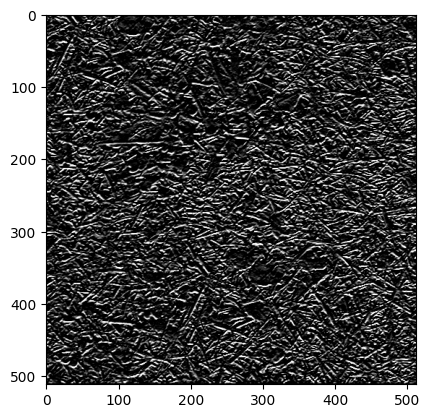

In [ ]:
image = cv2.imread("../data/images/grass.png",cv2.IMREAD_GRAYSCALE)
kernel = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

convolved_image = cv2.filter2D(image, -1, kernel)

plt.imshow(convolved_image, cmap='gray')
plt.show()

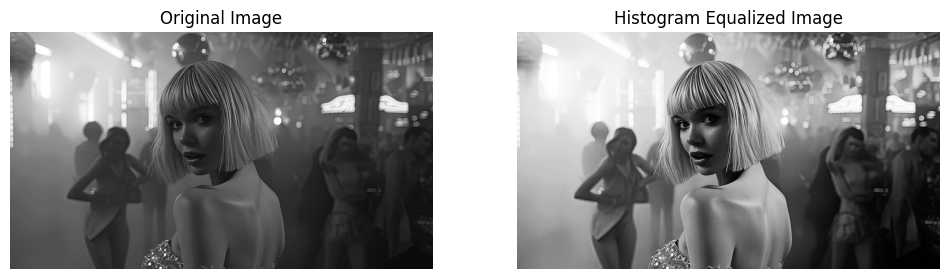

In [7]:
image = cv2.imread("../data/images/neonlady.png", cv2.IMREAD_GRAYSCALE)

# Apply histogram equalization
image_eq = cv2.equalizeHist(image)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_eq, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')

plt.show()

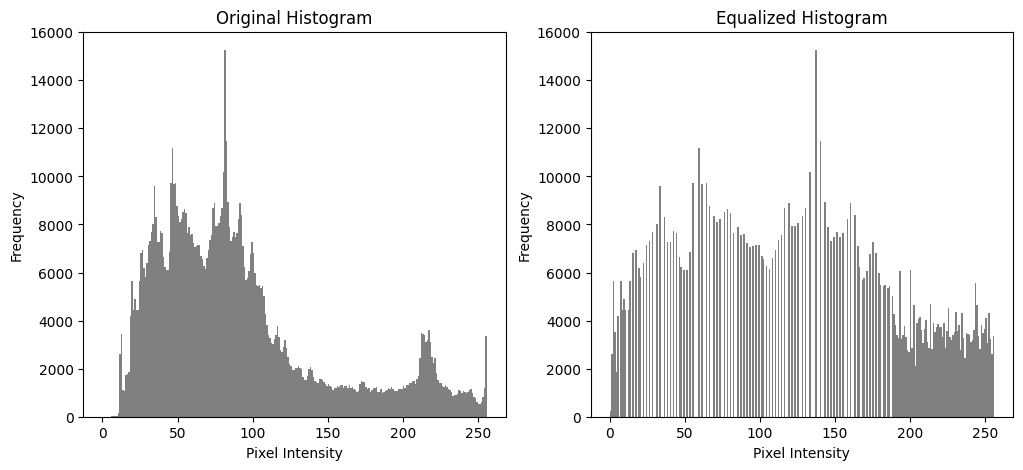

In [8]:
plt.figure(figsize=(12, 5))

# Original histogram
plt.subplot(1, 2, 1)
plt.hist(image.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# Equalized histogram
plt.subplot(1, 2, 2)
plt.hist(image_eq.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [9]:
# Apply Gaussian filters with different kernel sizes and sigma
gaussian_3x3 = cv2.GaussianBlur(image, (3, 3), sigmaX=0)
gaussian_5x5 = cv2.GaussianBlur(image, (5, 5), sigmaX=0)

# Apply box filter (average filter) for comparison
box_kernel_3 = np.ones((3, 3), np.float32) / 9
box_filter_3x3 = cv2.filter2D(image, -1, box_kernel_3)

box_kernel_5 = np.ones((5, 5), np.float32) / 25
box_filter_5x5 = cv2.filter2D(image, -1, box_kernel_5)

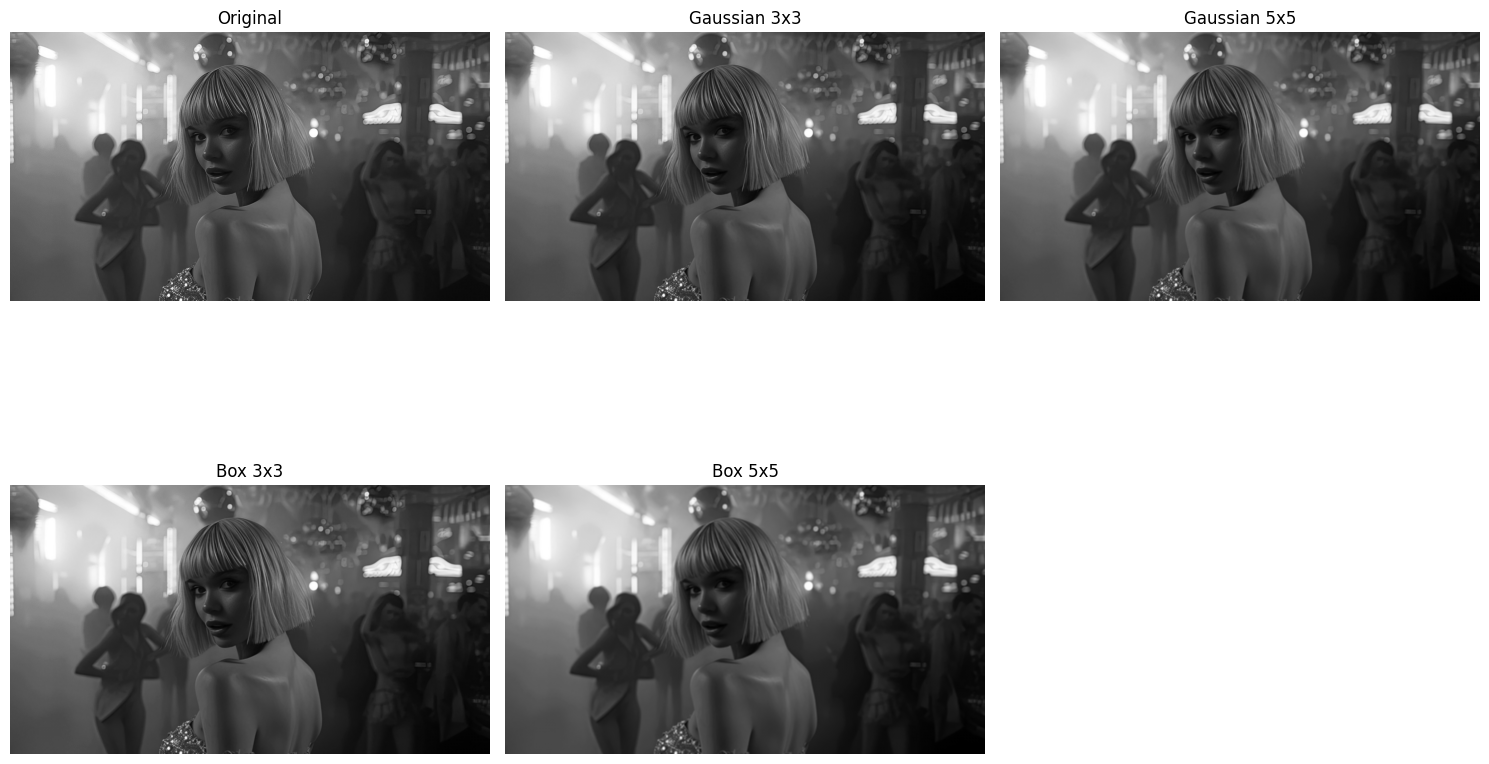

In [11]:
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

# Gaussian 3x3
plt.subplot(2, 3, 2)
plt.imshow(gaussian_3x3, cmap='gray')
plt.title("Gaussian 3x3")
plt.axis('off')

# Gaussian 5x5
plt.subplot(2, 3, 3)
plt.imshow(gaussian_5x5, cmap='gray')
plt.title("Gaussian 5x5")
plt.axis('off')

# Box 3x3
plt.subplot(2, 3, 4)
plt.imshow(box_filter_3x3, cmap='gray')
plt.title("Box 3x3")
plt.axis('off')

# Box 5x5
plt.subplot(2, 3, 5)
plt.imshow(box_filter_5x5, cmap='gray')
plt.title("Box 5x5")
plt.axis('off')

plt.tight_layout()
plt.show()

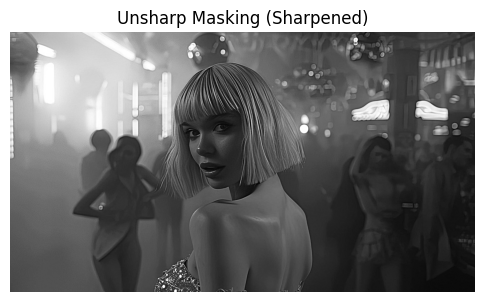

In [12]:
# Step 1: Apply Gaussian blur (part of unsharp masking)
# Kernel size 9x9, sigma=10
blurred = cv2.GaussianBlur(image, (9, 9), 10)

# Step 2 & 3: Combine original and edge-highlighted image
# Formula: sharpened = alpha*original + beta*blurred + gamma
# Using alpha=1.5, beta=-0.5, gamma=0
unsharp_image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

# Step 4: Display the result
plt.figure(figsize=(6, 6))
plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking (Sharpened)')
plt.axis('off')
plt.show()

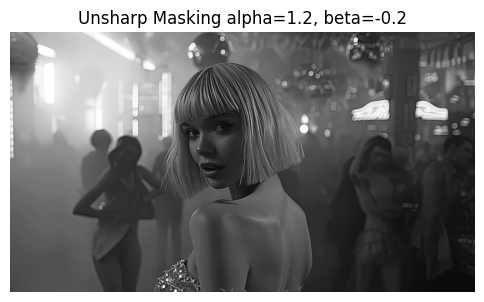

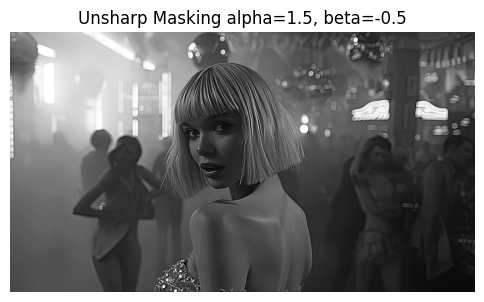

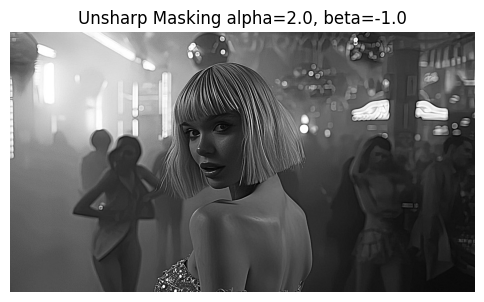

In [13]:
for alpha, beta in [(1.2, -0.2), (1.5, -0.5), (2.0, -1.0)]:
    unsharp = cv2.addWeighted(image, alpha, blurred, beta, 0)
    plt.figure(figsize=(6, 6))
    plt.imshow(unsharp, cmap='gray')
    plt.title(f'Unsharp Masking alpha={alpha}, beta={beta}')
    plt.axis('off')
    plt.show()

In [14]:
def box_filt(n):
    """Create a box filter kernel of size n x n"""
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    return np.ones((n, n), dtype=np.float32) / (n * n)

def apply_filters(image_input, box, filt_size):
    """Apply a box filter to an image manually"""
    row, column = image_input.shape
    pad_size = filt_size // 2
    image_padded = np.pad(image_input,
                          pad_width=((pad_size, pad_size), (pad_size, pad_size)),
                          mode='symmetric')
    image_box = image_input.copy()
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            image_box[i, j] = np.sum(box * patch_curr)
    return image_box

def unsharp_masking(image_input, filt_size, k):
    """Apply unsharp masking using a box filter"""
    box = box_filt(filt_size)
    image_blur = apply_filters(image_input, box, filt_size)
    image_diff = image_input - image_blur
    image_sharp = image_input + k * image_diff
    return np.clip(image_sharp, 0, 1)

In [17]:
filt_sizes = [3, 5, 7, 9, 11, 15]
k_values = [-2, -1, -0.5, 0, 0.5, 1, 2, 3, 5, 9]
image_input = cv2.imread("../data/images/neonlady.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)/255.0

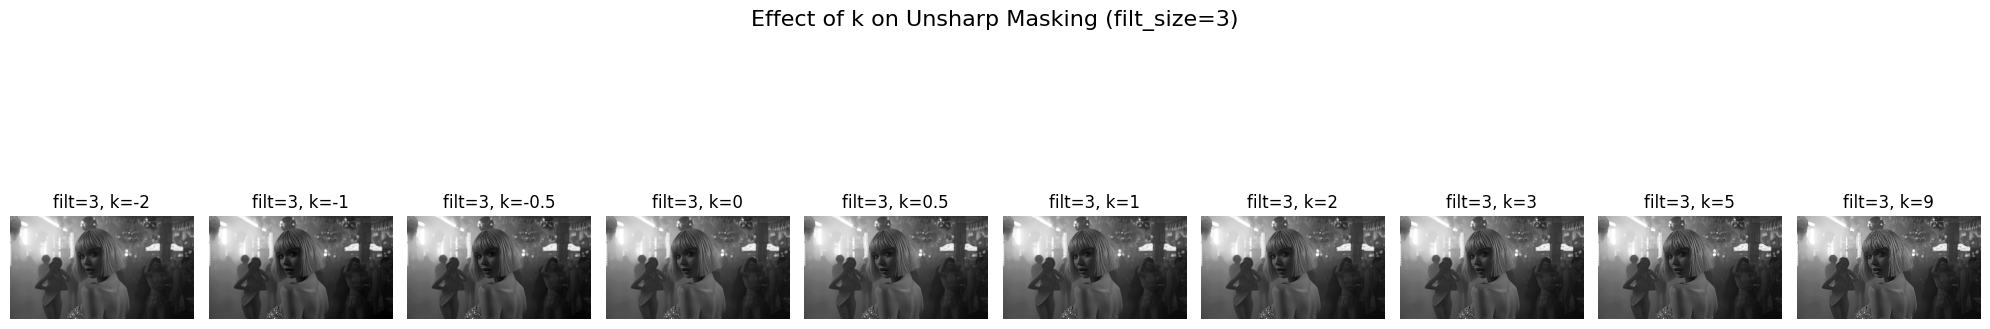

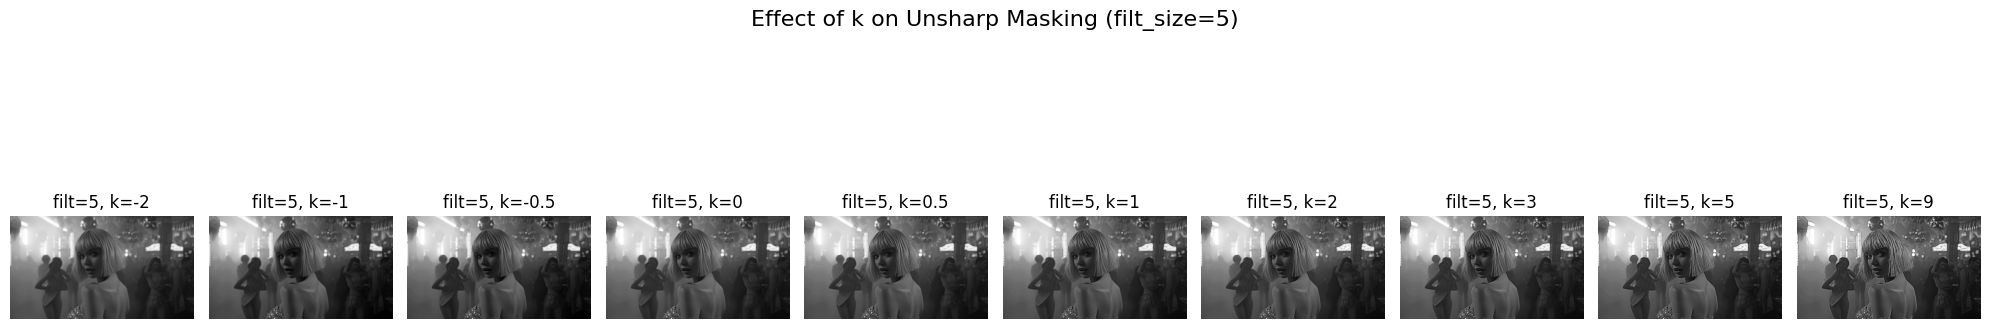

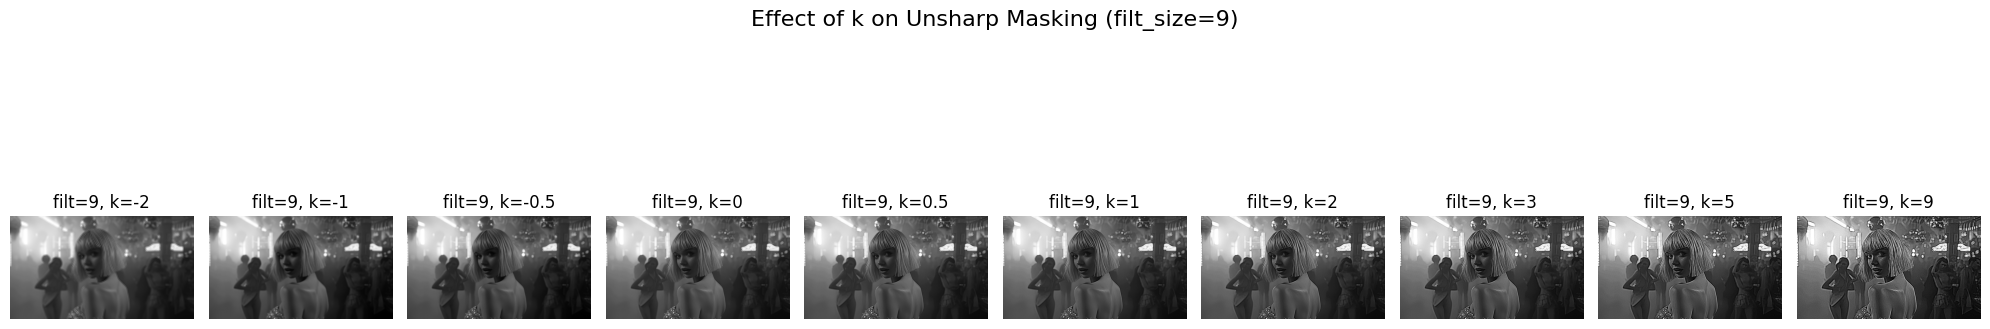

In [19]:
for filt_size in [3, 5, 9]:
    plt.figure(figsize=(20, 5))
    for idx, k in enumerate(k_values):
        image_sharp = unsharp_masking(image_input, filt_size, k)
        plt.subplot(1, len(k_values), idx+1)
        plt.imshow(image_sharp, cmap='gray')
        plt.title(f'filt={filt_size}, k={k}')
        plt.axis('off')
    plt.suptitle(f'Effect of k on Unsharp Masking (filt_size={filt_size})', fontsize=16)
    plt.tight_layout()
    plt.show()
     